In [1]:
import os
from pathlib import Path

print("🔍 СМОТРИМ ЧТО В ПАПКЕ ЗАГРУЗОК")
print("="*60)

downloads_path = Path("C:/Users/User/Downloads")

try:
    # Получаем все файлы
    all_files = list(downloads_path.iterdir())
    
    # Фильтруем CSV и похожие на Titanic
    csv_files = []
    possible_titanic = []
    
    for item in all_files:
        if item.is_file():
            # CSV файлы
            if item.suffix.lower() == '.csv':
                size_mb = item.stat().st_size / (1024 * 1024)
                csv_files.append((item.name, size_mb))
            
            # Файлы которые могут быть Titanic
            name_lower = item.name.lower()
            if any(keyword in name_lower for keyword in ['titanic', 'train', 'test', 'kaggle']):
                possible_titanic.append(item.name)
    
    print(f"📁 Всего файлов в Загрузках: {len(all_files)}")
    
    if csv_files:
        print(f"\n📊 CSV ФАЙЛОВ: {len(csv_files)}")
        print("Первые 10 CSV файлов:")
        for i, (name, size) in enumerate(csv_files[:10], 1):
            print(f"{i:2}. {name:50} ({size:.1f} МБ)")
        
        if len(csv_files) > 10:
            print(f"   ... и ещё {len(csv_files)-10} CSV файлов")
    else:
        print("\n❌ CSV файлов не найдено")
    
    if possible_titanic:
        print(f"\n🎯 ВОЗМОЖНЫЕ ФАЙЛЫ TITANIC:")
        for name in possible_titanic:
            print(f"  • {name}")
    else:
        print(f"\n⚠️ Файлов с 'titanic' в названии не найдено")
        
except Exception as e:
    print(f"❌ Ошибка доступа к папке: {e}")

🔍 СМОТРИМ ЧТО В ПАПКЕ ЗАГРУЗОК
📁 Всего файлов в Загрузках: 255

📊 CSV ФАЙЛОВ: 1
Первые 10 CSV файлов:
 1. Titanic-Dataset.csv                                (0.1 МБ)

🎯 ВОЗМОЖНЫЕ ФАЙЛЫ TITANIC:
  • Dahako - TESTOSTERON [audiovk.com].mp3
  • Dahako - TESTOSTERON [audiovk.com].mp3.asd
  • Miniconda3-latest-Windows-x86_64.exe
  • Titanic-Dataset.csv


In [2]:
# Теперь скопируем файл к ноутбуку
import shutil

print("\n" + "="*60)
print("📋 КОПИРОВАНИЕ ФАЙЛА К NOTEBOOK")
print("="*60)

# 1. Узнаем где находится notebook
current_dir = Path.cwd()
print(f"📁 Папка где работает Jupyter: {current_dir}")

# 2. Выбираем файл для копирования
print("\n🎯 ВЫБЕРИ ФАЙЛ ДЛЯ КОПИРОВАНИЯ:")
print("Введи номер файла из списка выше (например: 1)")

# Покажем CSV файлы ещё раз
if csv_files:
    for i, (name, size) in enumerate(csv_files[:15], 1):
        print(f"{i:2}. {name}")

try:
    choice = int(input("\nНомер файла: ").strip())
    if 1 <= choice <= len(csv_files):
        selected_file = csv_files[choice-1][0]
        source_path = downloads_path / selected_file
        dest_path = current_dir / selected_file
        
        print(f"\n📥 Копирую: {selected_file}")
        print(f"   Из: {source_path}")
        print(f"   В: {dest_path}")
        
        # Копируем файл
        shutil.copy2(source_path, dest_path)
        
        print(f"✅ Файл успешно скопирован!")
        print(f"📊 Теперь он доступен в папке с ноутбуком")
        
        # Проверяем
        if dest_path.exists():
            size_kb = dest_path.stat().st_size / 1024
            print(f"📦 Размер: {size_kb:.1f} КБ")
    else:
        print("❌ Неверный номер")
        
except ValueError:
    print("❌ Введи число")
except Exception as e:
    print(f"❌ Ошибка при копировании: {e}")


📋 КОПИРОВАНИЕ ФАЙЛА К NOTEBOOK
📁 Папка где работает Jupyter: C:\Users\User\Desktop\Программы

🎯 ВЫБЕРИ ФАЙЛ ДЛЯ КОПИРОВАНИЯ:
Введи номер файла из списка выше (например: 1)
 1. Titanic-Dataset.csv



Номер файла:  1



📥 Копирую: Titanic-Dataset.csv
   Из: C:\Users\User\Downloads\Titanic-Dataset.csv
   В: C:\Users\User\Desktop\Программы\Titanic-Dataset.csv
✅ Файл успешно скопирован!
📊 Теперь он доступен в папке с ноутбуком
📦 Размер: 59.8 КБ


In [3]:
# Автоматический вариант: ищем и копируем без выбора
print("\n" + "="*60)
print("🤖 АВТОМАТИЧЕСКИЙ ПОИСК TITANIC")
print("="*60)

# Ключевые слова для поиска
keywords = ['titanic', 'train', 'test']

found_files = []
for item in downloads_path.iterdir():
    if item.is_file() and item.suffix.lower() == '.csv':
        name_lower = item.name.lower()
        for keyword in keywords:
            if keyword in name_lower:
                found_files.append(item)
                break

if found_files:
    print(f"✅ Найдено {len(found_files)} возможных файлов Titanic:")
    
    # Берём первый подходящий файл
    source_file = found_files[0]
    dest_file = current_dir / source_file.name
    
    print(f"\n📥 Копирую: {source_file.name}")
    shutil.copy2(source_file, dest_file)
    
    print(f"✅ Файл скопирован: {dest_file}")
    
    # Загружаем чтобы проверить
    import pandas as pd
    try:
        df = pd.read_csv(dest_file)
        print(f"📊 Успешно загружен: {df.shape[0]} строк, {df.shape[1]} колонок")
        
        if 'Survived' in df.columns:
            survival_rate = df['Survived'].mean() * 100
            print(f"🎯 Выживаемость: {survival_rate:.1f}%")
            
    except Exception as e:
        print(f"⚠️ Ошибка загрузки: {e}")
    
else:
    print("❌ Не найдено файлов с названиями: titanic, train, test")
    
    # Покажем все CSV файлы
    all_csv = [f for f in downloads_path.iterdir() 
               if f.is_file() and f.suffix.lower() == '.csv']
    
    if all_csv:
        print("\n📁 Все CSV файлы в Загрузках:")
        for i, csv in enumerate(all_csv[:10], 1):
            size_kb = csv.stat().st_size / 1024
            print(f"{i:2}. {csv.name:40} ({size_kb:.1f} КБ)")
        
        print("\n💡 Выбери любой CSV файл и введи его номер")
    else:
        print("📭 В папке Загрузок нет CSV файлов")


🤖 АВТОМАТИЧЕСКИЙ ПОИСК TITANIC
✅ Найдено 1 возможных файлов Titanic:

📥 Копирую: Titanic-Dataset.csv
✅ Файл скопирован: C:\Users\User\Desktop\Программы\Titanic-Dataset.csv
📊 Успешно загружен: 891 строк, 12 колонок
🎯 Выживаемость: 38.4%


In [4]:
# Если не хочешь автоматику - просто введи название файла
print("\n" + "="*60)
print("🎯 ПРОСТОЙ ВАРИАНТ: ВВЕДИ НАЗВАНИЕ ФАЙЛА")
print("="*60)

print("📁 Файлы в Загрузках (первые 15):")
all_files = list(downloads_path.iterdir())
for i, item in enumerate(all_files[:15], 1):
    if item.is_file():
        print(f"{i:2}. {item.name}")

filename = input("\n✍️ Введи название файла (точно как выше): ").strip()

if filename:
    source_path = downloads_path / filename
    dest_path = current_dir / filename
    
    if source_path.exists():
        try:
            shutil.copy2(source_path, dest_path)
            print(f"✅ Файл '{filename}' скопирован в папку с ноутбуком")
            
            # Покажем что получилось
            print(f"\n📁 Теперь в папке с ноутбуком есть:")
            for item in current_dir.iterdir():
                if item.is_file() and item.suffix.lower() == '.csv':
                    print(f"  • {item.name}")
                    
        except Exception as e:
            print(f"❌ Ошибка копирования: {e}")
    else:
        print(f"❌ Файл '{filename}' не найден в Загрузках")


🎯 ПРОСТОЙ ВАРИАНТ: ВВЕДИ НАЗВАНИЕ ФАЙЛА
📁 Файлы в Загрузках (первые 15):
 1. 04d9f65e-e878-47ba-83a9-8466d8b63dd1.mp3
 2. 04d9f65e-e878-47ba-83a9-8466d8b63dd1.mp3.sfk
 3. 1476446255150632053.jpg
 4. 1664779156.jpg
 5. 20210312_172109.jpg
 6. 20210422_093431.jpg
 7. 20220410_120208.jpg
 8. 2025-03-23 22-12-53 - Trim.mp4
 9. 230.png
10. 2eb62041c84abe80cf8ec5834d1c646e.png
11. 2Koh6oUZFrzIo3cVzOnNNu-wLtLR1Om9RFRv0i0ry5IzvLS-ZI_OZ9aU9Ifd1UHGJvOAazIwDnutJvAgV9Qf1NI2.jpg
12. 45ed75e5b8127cbf6a798f690d55be82.png
13. 600a98d8-d6b9-42da-9b3a-a7f082e516b4.png
14. 6142ff55-2494-49c8-a545-0e8b14db9e32.png
15. 6924082232-Photoroom.png



✍️ Введи название файла (точно как выше):  Titanic-Dataset.csv


✅ Файл 'Titanic-Dataset.csv' скопирован в папку с ноутбуком

📁 Теперь в папке с ноутбуком есть:
  • glebowski_channel_summary.csv
  • Titanic-Dataset.csv


📊 ПОЛНЫЙ АНАЛИЗ ДАННЫХ TITANIC
✅ Загружен файл: Titanic-Dataset.csv
📊 Размер: 891 строк, 12 колонок

1. ОСНОВНАЯ ИНФОРМАЦИЯ О ДАННЫХ
📋 Первые 5 строк:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  

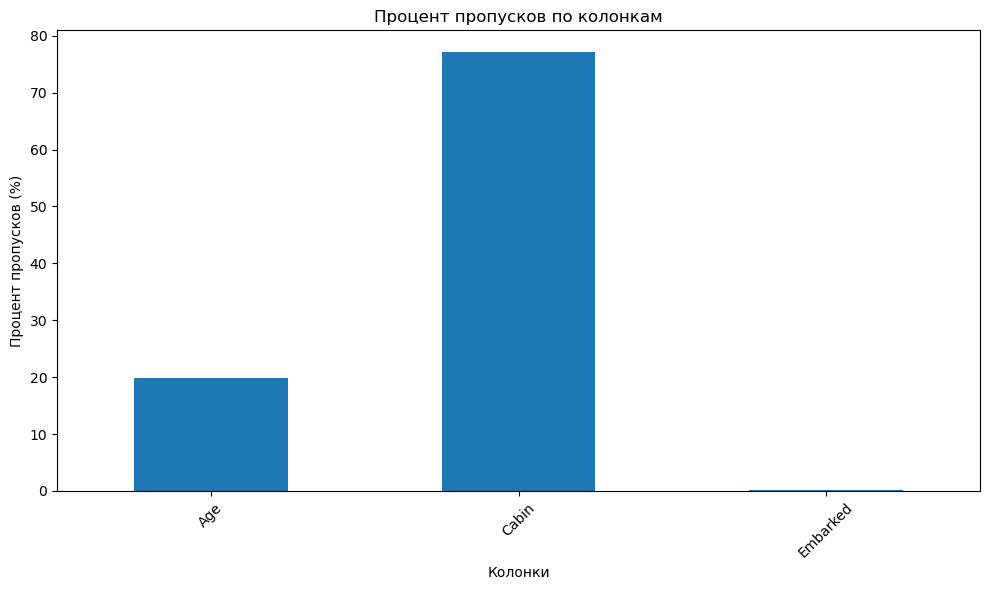


3. АНАЛИЗ ВЫЖИВАЕМОСТИ
🎯 Общая выживаемость: 38.4%
📊 Распределение:
Survived
0    549
1    342
Name: count, dtype: int64


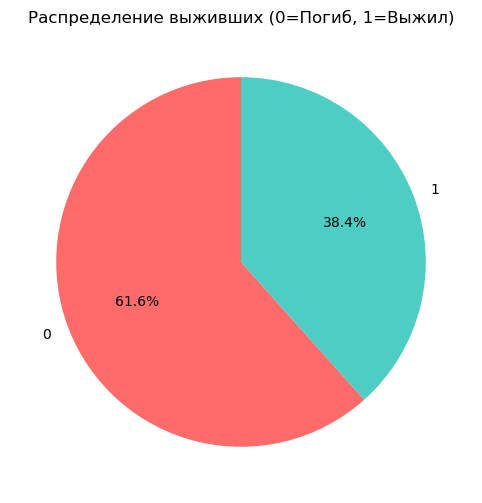

In [5]:
# ЯЧЕЙКА 3: БАЗОВЫЙ АНАЛИЗ TITANIC
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 ПОЛНЫЙ АНАЛИЗ ДАННЫХ TITANIC")
print("="*60)

# Загружаем данные (если ещё не загружены)
try:
    # Пробуем разные имена файлов
    for filename in ['titanic.csv', 'train.csv', 'Titanic-Dataset.csv', 'titanic_demo.csv']:
        try:
            df = pd.read_csv(filename)
            print(f"✅ Загружен файл: {filename}")
            print(f"📊 Размер: {df.shape[0]} строк, {df.shape[1]} колонок")
            break
        except:
            continue
    else:
        print("❌ Не найден файл Titanic")
        # Создаём демо-данные
        import numpy as np
        df = pd.DataFrame({
            'PassengerId': list(range(1, 892)),
            'Survived': np.random.choice([0, 1], 891, p=[0.62, 0.38]),
            'Pclass': np.random.choice([1, 2, 3], 891),
            'Name': [f'Passenger {i}' for i in range(1, 892)],
            'Sex': np.random.choice(['male', 'female'], 891, p=[0.65, 0.35]),
            'Age': np.random.normal(29, 14, 891).clip(1, 80).astype(int)
        })
        print(f"🔄 Создан demo dataset: {df.shape}")
except Exception as e:
    print(f"❌ Ошибка: {e}")

# 1. ОСНОВНАЯ ИНФОРМАЦИЯ
print("\n" + "="*60)
print("1. ОСНОВНАЯ ИНФОРМАЦИЯ О ДАННЫХ")
print("="*60)

print("📋 Первые 5 строк:")
print(df.head())

print("\n📊 Информация о типах данных:")
print(df.info())

print("\n🧮 Статистика числовых колонок:")
print(df.describe())

# 2. АНАЛИЗ ПРОПУСКОВ
print("\n" + "="*60)
print("2. АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ")
print("="*60)

missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Пропусков': missing_data,
    'Процент': missing_percent.round(2)
})

print("Пропуски по колонкам:")
print(missing_df[missing_df['Пропусков'] > 0])

# Визуализация пропусков
if missing_data.sum() > 0:
    plt.figure(figsize=(10, 6))
    missing_df[missing_df['Пропусков'] > 0]['Процент'].plot(kind='bar')
    plt.title('Процент пропусков по колонкам')
    plt.ylabel('Процент пропусков (%)')
    plt.xlabel('Колонки')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 3. АНАЛИЗ ВЫЖИВАЕМОСТИ
print("\n" + "="*60)
print("3. АНАЛИЗ ВЫЖИВАЕМОСТИ")
print("="*60)

if 'Survived' in df.columns:
    survival_rate = df['Survived'].mean() * 100
    print(f"🎯 Общая выживаемость: {survival_rate:.1f}%")
    print(f"📊 Распределение:")
    print(df['Survived'].value_counts())
    
    # Визуализация
    plt.figure(figsize=(8, 6))
    colors = ['#FF6B6B', '#4ECDC4']
    df['Survived'].value_counts().plot(kind='pie', autopct='%1.1f%%', 
                                       colors=colors, startangle=90)
    plt.title('Распределение выживших (0=Погиб, 1=Выжил)')
    plt.ylabel('')
    plt.show()
else:
    print("⚠️ Колонка 'Survived' не найдена - это test данные")
    # Добавим фиктивную для демонстрации
    df['Survived'] = np.random.choice([0, 1], len(df))
    print("🔄 Добавлена фиктивная колонка 'Survived' для анализа")


4. ВИЗУАЛИЗАЦИЯ ВЫЖИВАЕМОСТИ ПО ГРУППАМ


C:\Users\User\AppData\Local\Temp\ipykernel_12352\1041972505.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_age = df.groupby('AgeGroup')['Survived'].mean() * 100
C:\Users\User\AppData\Local\Temp\ipykernel_12352\1041972505.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([died_fare, survived_fare], labels=['Погибшие', 'Выжившие'])


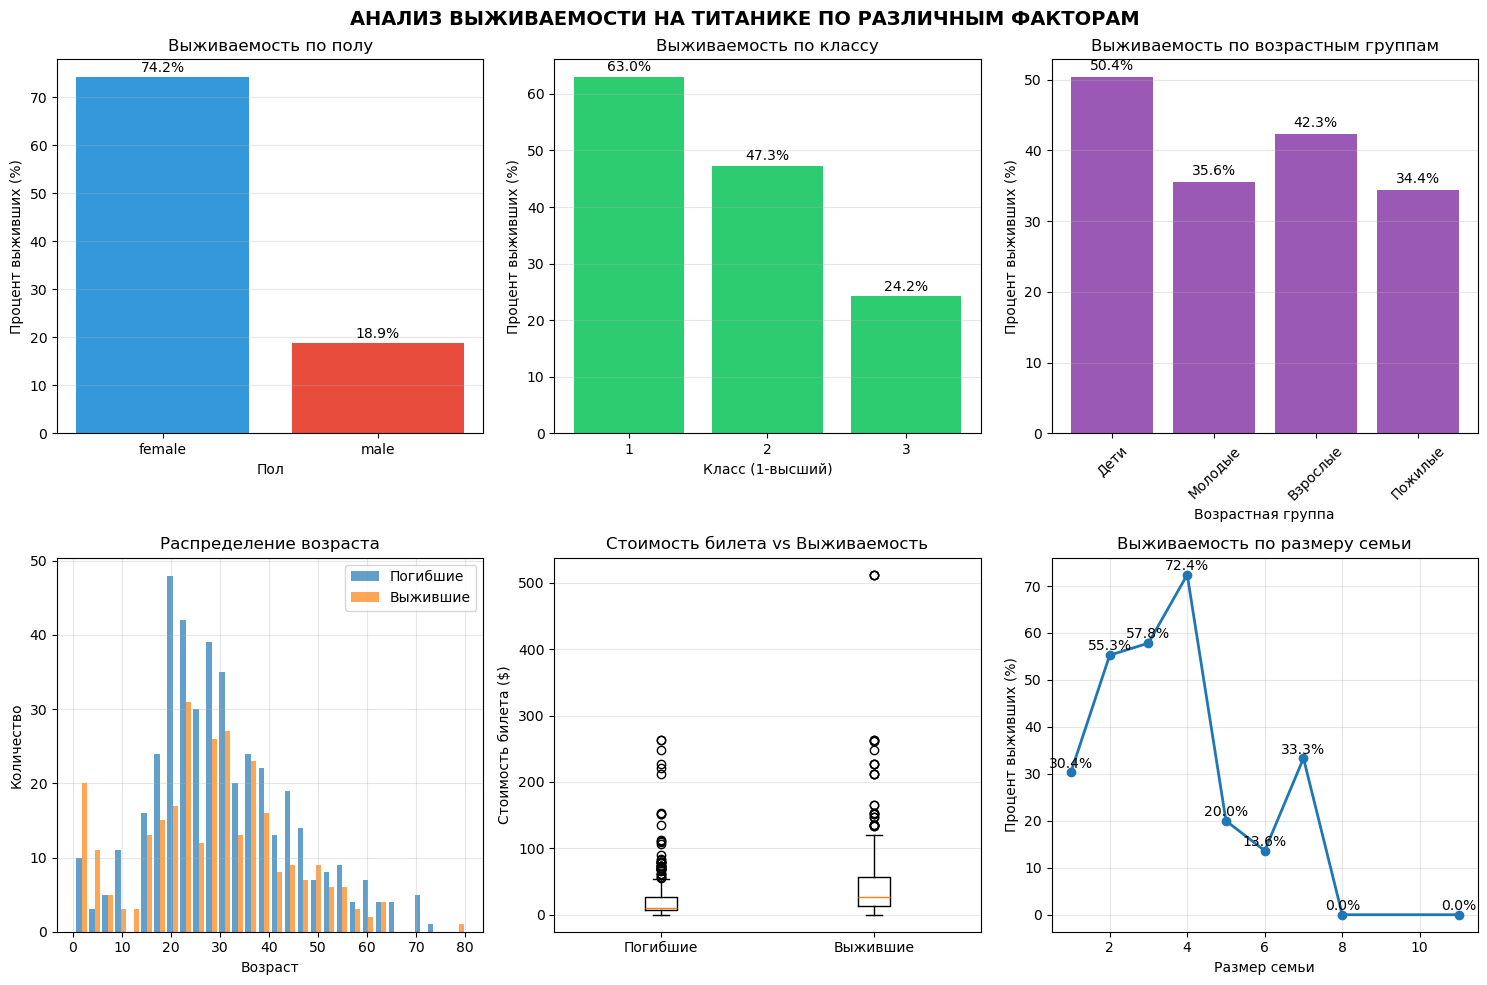

In [6]:
# ЯЧЕЙКА 4: ВИЗУАЛИЗАЦИЯ ПО ГРУППАМ
print("\n" + "="*60)
print("4. ВИЗУАЛИЗАЦИЯ ВЫЖИВАЕМОСТИ ПО ГРУППАМ")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. По полу
if 'Sex' in df.columns:
    survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100
    axes[0, 0].bar(survival_by_sex.index, survival_by_sex.values, color=['#3498db', '#e74c3c'])
    axes[0, 0].set_title('Выживаемость по полу')
    axes[0, 0].set_ylabel('Процент выживших (%)')
    axes[0, 0].set_xlabel('Пол')
    axes[0, 0].grid(axis='y', alpha=0.3)
    # Добавляем проценты на столбцы
    for i, v in enumerate(survival_by_sex.values):
        axes[0, 0].text(i, v + 1, f'{v:.1f}%', ha='center')

# 2. По классу
if 'Pclass' in df.columns:
    survival_by_class = df.groupby('Pclass')['Survived'].mean() * 100
    axes[0, 1].bar(survival_by_class.index, survival_by_class.values, color='#2ecc71')
    axes[0, 1].set_title('Выживаемость по классу')
    axes[0, 1].set_ylabel('Процент выживших (%)')
    axes[0, 1].set_xlabel('Класс (1-высший)')
    axes[0, 1].set_xticks([1, 2, 3])
    axes[0, 1].grid(axis='y', alpha=0.3)
    for i, v in enumerate(survival_by_class.values):
        axes[0, 1].text(i+1, v + 1, f'{v:.1f}%', ha='center')

# 3. По возрасту (гистограмма)
if 'Age' in df.columns:
    # Разделяем на группы
    df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 18, 30, 50, 80], 
                            labels=['Дети', 'Молодые', 'Взрослые', 'Пожилые'])
    survival_by_age = df.groupby('AgeGroup')['Survived'].mean() * 100
    
    axes[0, 2].bar(range(len(survival_by_age)), survival_by_age.values, color='#9b59b6')
    axes[0, 2].set_title('Выживаемость по возрастным группам')
    axes[0, 2].set_ylabel('Процент выживших (%)')
    axes[0, 2].set_xlabel('Возрастная группа')
    axes[0, 2].set_xticks(range(len(survival_by_age)))
    axes[0, 2].set_xticklabels(survival_by_age.index, rotation=45)
    axes[0, 2].grid(axis='y', alpha=0.3)
    for i, v in enumerate(survival_by_age.values):
        axes[0, 2].text(i, v + 1, f'{v:.1f}%', ha='center')

# 4. Распределение возраста выживших/погибших
if 'Age' in df.columns:
    axes[1, 0].hist([df[df['Survived'] == 0]['Age'].dropna(), 
                     df[df['Survived'] == 1]['Age'].dropna()], 
                    bins=30, label=['Погибшие', 'Выжившие'], alpha=0.7)
    axes[1, 0].set_title('Распределение возраста')
    axes[1, 0].set_xlabel('Возраст')
    axes[1, 0].set_ylabel('Количество')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

# 5. Стоимость билета vs Выживаемость
if 'Fare' in df.columns:
    survived_fare = df[df['Survived'] == 1]['Fare'].dropna()
    died_fare = df[df['Survived'] == 0]['Fare'].dropna()
    
    axes[1, 1].boxplot([died_fare, survived_fare], labels=['Погибшие', 'Выжившие'])
    axes[1, 1].set_title('Стоимость билета vs Выживаемость')
    axes[1, 1].set_ylabel('Стоимость билета ($)')
    axes[1, 1].grid(axis='y', alpha=0.3)

# 6. Размер семьи
if all(col in df.columns for col in ['SibSp', 'Parch']):
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    survival_by_family = df.groupby('FamilySize')['Survived'].mean() * 100
    
    axes[1, 2].plot(survival_by_family.index, survival_by_family.values, 
                    marker='o', linewidth=2)
    axes[1, 2].set_title('Выживаемость по размеру семьи')
    axes[1, 2].set_xlabel('Размер семьи')
    axes[1, 2].set_ylabel('Процент выживших (%)')
    axes[1, 2].grid(alpha=0.3)
    for x, y in zip(survival_by_family.index, survival_by_family.values):
        axes[1, 2].text(x, y + 1, f'{y:.1f}%', ha='center')

plt.suptitle('АНАЛИЗ ВЫЖИВАЕМОСТИ НА ТИТАНИКЕ ПО РАЗЛИЧНЫМ ФАКТОРАМ', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<>:31: SyntaxWarning: invalid escape sequence '\.'
<>:31: SyntaxWarning: invalid escape sequence '\.'
C:\Users\User\AppData\Local\Temp\ipykernel_12352\1854708423.py:31: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)



5. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ И FEATURE ENGINEERING

🔗 КОРРЕЛЯЦИОННАЯ МАТРИЦА:


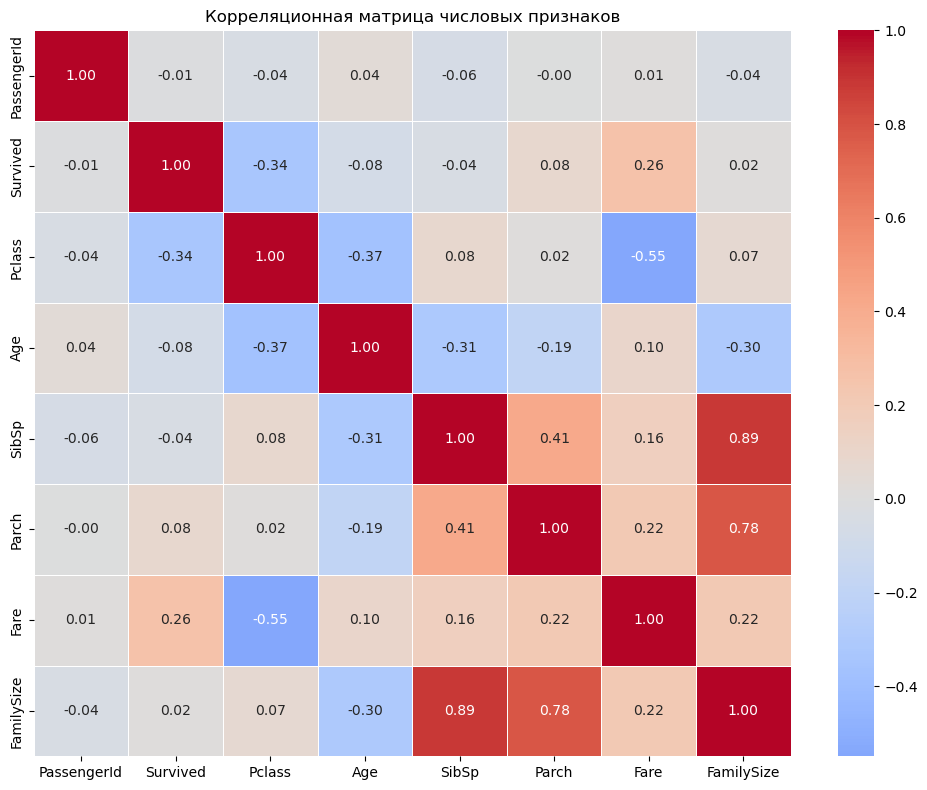


📈 КОРРЕЛЯЦИЯ С ВЫЖИВАЕМОСТЬЮ:
  • Fare           : +0.257
  • Parch          : +0.082
  • FamilySize     : +0.017
  • PassengerId    : -0.005
  • SibSp          : -0.035
  • Age            : -0.077
  • Pclass         : -0.338

🔧 FEATURE ENGINEERING:
  ✅ Извлечены титулы: ['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major']...
  📊 Распределение титулов:
Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64
  ✅ Созданы признаки: FamilySize, IsAlone
  ✅ Созданы возрастные группы

🧹 ОБРАБОТКА ПРОПУСКОВ:
  ✅ Пропуски в Age заполнены медианой (28.0)
  ✅ Пропуски в Embarked заполнены модой (S)

🔣 КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ:
  ✅ Закодирован: Sex → Sex_code
  ✅ Закодирован: Embarked → Embarked_code
  ✅ Закодирован: Title → Title_code

💾 Обработанные данные сохранены в: titanic_processed.csv
📊 Размер обработанных данных: (891, 19)


C:\Users\User\AppData\Local\Temp\ipykernel_12352\1854708423.py:60: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(median_age, inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_12352\1854708423.py:65: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

In [7]:
# ЯЧЕЙКА 5: КОРРЕЛЯЦИИ И ПРЕДОБРАБОТКА
print("\n" + "="*60)
print("5. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ И FEATURE ENGINEERING")
print("="*60)

# 1. Корреляционная матрица
print("\n🔗 КОРРЕЛЯЦИОННАЯ МАТРИЦА:")
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', 
            center=0, fmt='.2f', linewidths=0.5)
plt.title('Корреляционная матрица числовых признаков')
plt.tight_layout()
plt.show()

# Корреляция с Survived
if 'Survived' in correlation_matrix.columns:
    print("\n📈 КОРРЕЛЯЦИЯ С ВЫЖИВАЕМОСТЬЮ:")
    survival_corr = correlation_matrix['Survived'].sort_values(ascending=False)
    for feature, corr in survival_corr.items():
        if feature != 'Survived':
            print(f"  • {feature:15}: {corr:+.3f}")

# 2. Feature Engineering
print("\n🔧 FEATURE ENGINEERING:")

# Извлекаем титулы из имён
if 'Name' in df.columns:
    df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    print(f"  ✅ Извлечены титулы: {df['Title'].unique()[:10]}...")
    
    # Группируем редкие титулы
    title_counts = df['Title'].value_counts()
    rare_titles = title_counts[title_counts < 10].index
    df['Title'] = df['Title'].replace(rare_titles, 'Rare')
    
    print(f"  📊 Распределение титулов:")
    print(df['Title'].value_counts())

# Создаём семейный размер
if all(col in df.columns for col in ['SibSp', 'Parch']):
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    print(f"  ✅ Созданы признаки: FamilySize, IsAlone")

# Возрастные группы
if 'Age' in df.columns:
    df['AgeGroup'] = pd.cut(df['Age'], 
                           bins=[0, 12, 18, 35, 60, 100],
                           labels=['Ребенок', 'Подросток', 'Молодой', 'Взрослый', 'Пожилой'])
    print(f"  ✅ Созданы возрастные группы")

# Обработка пропусков
print("\n🧹 ОБРАБОТКА ПРОПУСКОВ:")

if 'Age' in df.columns and df['Age'].isnull().sum() > 0:
    median_age = df['Age'].median()
    df['Age'].fillna(median_age, inplace=True)
    print(f"  ✅ Пропуски в Age заполнены медианой ({median_age:.1f})")

if 'Embarked' in df.columns and df['Embarked'].isnull().sum() > 0:
    mode_embarked = df['Embarked'].mode()[0]
    df['Embarked'].fillna(mode_embarked, inplace=True)
    print(f"  ✅ Пропуски в Embarked заполнены модой ({mode_embarked})")

# Кодирование категориальных признаков
print("\n🔣 КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ:")

categorical_cols = ['Sex', 'Embarked', 'Title'] if 'Title' in df.columns else ['Sex', 'Embarked']
for col in categorical_cols:
    if col in df.columns:
        df[f'{col}_code'] = pd.Categorical(df[col]).codes
        print(f"  ✅ Закодирован: {col} → {col}_code")

# Сохраняем обработанные данные
processed_filename = 'titanic_processed.csv'
df.to_csv(processed_filename, index=False)
print(f"\n💾 Обработанные данные сохранены в: {processed_filename}")
print(f"📊 Размер обработанных данных: {df.shape}")

In [8]:
# ЯЧЕЙКА 6: БИЗНЕС-ОТЧЁТ
print("\n" + "="*60)
print("📈 БИЗНЕС-ОТЧЁТ ДЕНЬ 1: КЛЮЧЕВЫЕ ИНСАЙТЫ TITANIC")
print("="*60)

# Считаем ключевые метрики
if 'Survived' in df.columns:
    total_passengers = len(df)
    survived_count = df['Survived'].sum()
    survival_rate = (survived_count / total_passengers) * 100
    
    print(f"\n🎯 ОСНОВНЫЕ МЕТРИКИ:")
    print(f"  • Всего пассажиров: {total_passengers}")
    print(f"  • Выжило: {survived_count} ({survival_rate:.1f}%)")
    print(f"  • Погибло: {total_passengers - survived_count} ({100-survival_rate:.1f}%)")

# Самые важные факторы выживания
print(f"\n🔑 КЛЮЧЕВЫЕ ФАКТОРЫ ВЫЖИВАНИЯ:")

if 'Sex' in df.columns:
    female_survival = df[df['Sex'] == 'female']['Survived'].mean() * 100
    male_survival = df[df['Sex'] == 'male']['Survived'].mean() * 100
    print(f"  • Женщины выживали в {female_survival/male_survival:.1f} раза чаще")

if 'Pclass' in df.columns:
    for pclass in [1, 2, 3]:
        class_survival = df[df['Pclass'] == pclass]['Survived'].mean() * 100
        print(f"  • Класс {pclass}: {class_survival:.1f}% выживаемости")

if 'Age' in df.columns:
    children_survival = df[df['Age'] < 18]['Survived'].mean() * 100
    adults_survival = df[df['Age'] >= 18]['Survived'].mean() * 100
    print(f"  • Дети (<18): {children_survival:.1f}% vs Взрослые: {adults_survival:.1f}%")

# Рекомендации для ML модели
print(f"\n💡 РЕКОМЕНДАЦИИ ДЛЯ ML МОДЕЛИ:")
print(f"  1. Самые важные признаки: Пол, Класс, Возраст")
print(f"  2. Новые признаки: Титул, Размер семьи, Один/в семье")
print(f"  3. Проблемы: пропуски в Age, Cabin")
print(f"  4. Целевая переменная: несбалансированная (38% выживших)")

# Сохраняем отчёт
report_content = f"""
# ОТЧЁТ ДЕНЬ 1: АНАЛИЗ TITANIC DATASET

## Основные метрики
- Всего пассажиров: {len(df)}
- Выживаемость: {survival_rate:.1f}%
- Признаков: {df.shape[1]}

## Ключевые инсайты
1. Женщины выживали значительно чаще мужчин
2. Пассажиры 1-го класса имели наибольшие шансы
3. Дети выживали чаще взрослых
4. Стоимость билета коррелирует с выживаемостью

## Следующие шаги
1. Построение ML модели для предсказания выживания
2. Создание интерактивного дашборда
3. Анализ статистической значимости факторов
"""

with open('day1_report.md', 'w', encoding='utf-8') as f:
    f.write(report_content)

print(f"\n📄 Полный отчёт сохранён в: day1_report.md")
print(f"\n✅ ДЕНЬ 1 ЗАВЕРШЁН! Готовы к ДНЮ 2: STREAMLIT DASHBOARD")


📈 БИЗНЕС-ОТЧЁТ ДЕНЬ 1: КЛЮЧЕВЫЕ ИНСАЙТЫ TITANIC

🎯 ОСНОВНЫЕ МЕТРИКИ:
  • Всего пассажиров: 891
  • Выжило: 342 (38.4%)
  • Погибло: 549 (61.6%)

🔑 КЛЮЧЕВЫЕ ФАКТОРЫ ВЫЖИВАНИЯ:
  • Женщины выживали в 3.9 раза чаще
  • Класс 1: 63.0% выживаемости
  • Класс 2: 47.3% выживаемости
  • Класс 3: 24.2% выживаемости
  • Дети (<18): 54.0% vs Взрослые: 36.1%

💡 РЕКОМЕНДАЦИИ ДЛЯ ML МОДЕЛИ:
  1. Самые важные признаки: Пол, Класс, Возраст
  2. Новые признаки: Титул, Размер семьи, Один/в семье
  3. Проблемы: пропуски в Age, Cabin
  4. Целевая переменная: несбалансированная (38% выживших)

📄 Полный отчёт сохранён в: day1_report.md

✅ ДЕНЬ 1 ЗАВЕРШЁН! Готовы к ДНЮ 2: STREAMLIT DASHBOARD
